# Troligen ska denna fil raderas. Behåller temporärt någon del av koden skulle vara användbar att kopiera till en annan fil.

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from utils.general_classes import *
from robustness.milp_functions import *
import matplotlib.pyplot as plt
import numpy as np
from training import *
from utils.other_functions import *
from architectures import LeNet
from architectures.CNNBuilder import *
from utils import extractParams

Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 3600


C:\Users\adaml\AppData\Local\Temp\ipykernel_12300\2982333910.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp_model.load_state_dict(torch.load('PyTorchModels/model_A.

Optimal solution found!
25.649733262373417


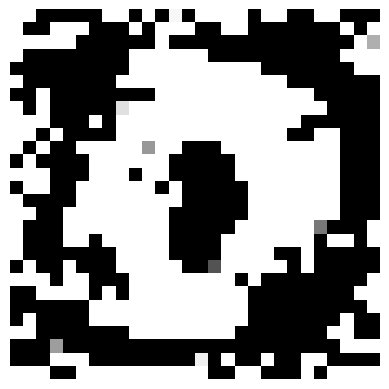

In [ ]:
mlp_model = SmallDense1()
mlp_model.load_state_dict(torch.load('networks/smallDense1.pth'))

mlp_bridge = ModelBridge(mlp_model)
# Note: MLP input_shape can be inferred as (784,)
mlp_bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
mlp_bridge.setup_gurobi_logic()

img, obj_val = feature_selection(mlp_bridge, 0, mode="second place relative")

print(obj_val)
reshaped_image = np.reshape(img, shape=(28,28))
plt.imshow(reshaped_image, cmap='gray')
plt.axis('off')  # optional: hides axis
plt.show()

Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 3600


C:\Users\adaml\AppData\Local\Temp\ipykernel_12300\2401275758.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp_model.load_state_dict(torch.load('PyTorchModels/model_A.

Starting search for optimal solution
Num variables not including the robustness testing: 1034
Num constraints not including the robustness testing: 410
Num binary variables not including the robustness testing: 80
Num variables including the robustness testing: 1828
Num constraints including the robustness testing: 1980
Num binary variables including the robustness testing: 90
Optimal solution found!


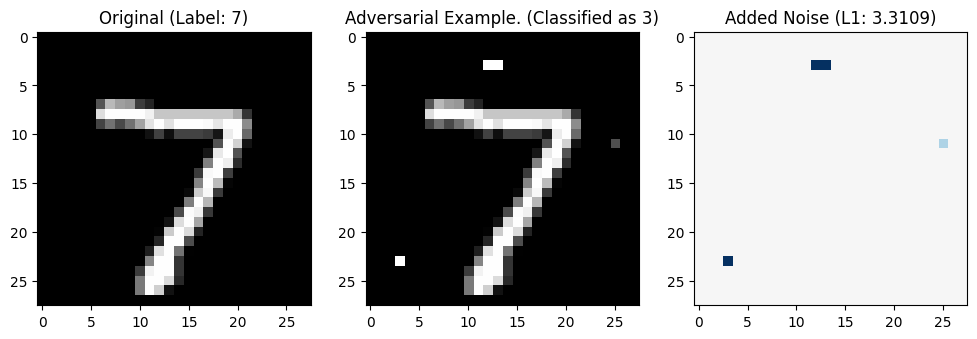

In [ ]:
# For MLP
mlp_model = SmallDense1()
mlp_model.load_state_dict(torch.load('networks/smallDense1.pth'))

mlp_bridge = ModelBridge(mlp_model)
# Note: MLP input_shape can be inferred as (784,)
mlp_bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
mlp_bridge.setup_gurobi_logic()


# Get sample 
sample_number = 0
test_data = datasets.MNIST(root='./data', train=False, download=True, transform = transform)
image, label = test_data[sample_number]
image_flat = image.view(-1).numpy()

robustness_setup(image_flat, label, mlp_bridge, g_model=mlp_bridge.gurobi_model, max_d=1.0)
obj_val, adv_img, adv_classification = standard_robustness_test(mlp_bridge, g_model=mlp_bridge.gurobi_model, print_var_count=True)

adverserial_visualization(image, label, adv_img, obj_val, adv_classification)